# Inhomogeneous Spatiotemporal Poisson Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/ipp_spatiotemporal_from_scratch_and_numpyro.ipynb)

An **inhomogeneous spatiotemporal Poisson process** (IPP-ST) lets the rate vary across the slab $D \times [t_0, t_1)$:

$$
\lambda(s, t) > 0, \qquad
\Lambda = \int_{t_0}^{t_1}\!\int_D \lambda(s, t)\, ds\, dt,
$$

with Janossy log-likelihood $\sum_i \log \lambda(s_i, t_i) - \Lambda$. We use an **aftershock-style** intensity — Omori-law decay in time around a peak time, Gaussian-bump decay in space around an epicentre — sample with Lewis–Shedler thinning, and recover the mainshock parameters with NumPyro NUTS.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes import (
    RectangularDomain,
    TemporalDomain,
    integrate_log_intensity_spatiotemporal,
)
from xtremax.point_processes.distributions import (
    InhomogeneousSpatioTemporalPP as IppStDist,
)
from xtremax.point_processes.operators import (
    InhomogeneousSpatioTemporalPP as IppStOp,
)
from xtremax.point_processes.primitives import (
    ipp_spatiotemporal_log_prob,
    ipp_spatiotemporal_sample_thinning,
)


plt.rcParams["figure.figsize"] = (8.0, 4.0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From scratch — the primitives layer

Aftershock intensity around an epicentre $s_0$:

$$
\log \lambda(s, t) = \log A - \frac{\|s - s_0\|^2}{2\sigma^2} - \log(c + t).
$$

Peak intensity is at $(s_0, t = 0)$ with value $A / c$.

In [2]:
spatial = RectangularDomain.from_size(jnp.array([10.0, 10.0]))
temporal = TemporalDomain.from_duration(8.0)

epicentre = jnp.array([5.0, 5.0])
A_true = 8.0
sigma_true = 1.5
c_true = 0.5


def log_intensity(s, t, A=A_true, sigma=sigma_true, c=c_true, eps=1e-3):
    spatial_part = -0.5 * jnp.sum((s - epicentre) ** 2, axis=-1) / (sigma**2)
    temporal_part = -jnp.log(c + t)
    return jnp.log(A) + spatial_part + temporal_part - jnp.log(2.0 * jnp.pi * sigma**2)


lambda_max = A_true / c_true / (2.0 * jnp.pi * sigma_true**2)
print(f"λ_max = {float(lambda_max):.3f}")

key = random.PRNGKey(0)
locs, times, mask, _ = ipp_spatiotemporal_sample_thinning(
    key,
    log_intensity_fn=log_intensity,
    spatial=spatial,
    temporal=temporal,
    lambda_max=lambda_max,
    max_candidates=1024,
)
print(f"Drew {int(mask.sum())} aftershocks.")

λ_max = 1.132


Drew 17 aftershocks.


Plot the realisation: events clustered around the epicentre and the early time window, fading out as $t$ grows.

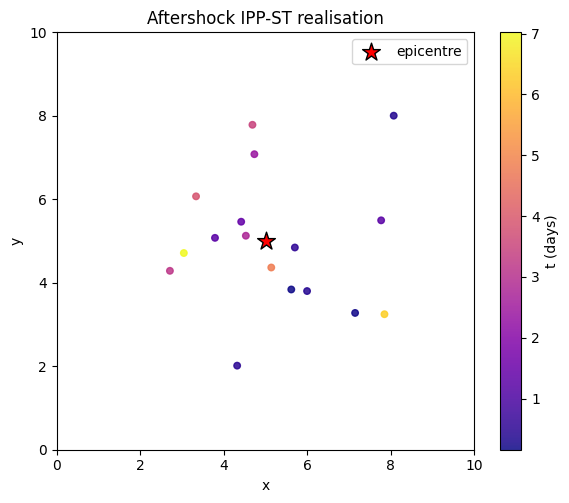

In [3]:
real_locs = locs[mask]
real_times = times[mask]
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    real_locs[:, 0], real_locs[:, 1], c=real_times, s=22, alpha=0.85, cmap="plasma"
)
ax.scatter(
    [5.0], [5.0], marker="*", s=180, color="red", edgecolor="k", label="epicentre"
)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Aftershock IPP-ST realisation")
ax.legend()
plt.colorbar(sc, ax=ax, label="t (days)")
plt.tight_layout()
plt.show()

### Log-likelihood and integrated intensity

`integrate_log_intensity_spatiotemporal` computes $\Lambda$ over the slab via Halton-QMC. The Janossy log-prob is then $\sum_i \log \lambda(s_i, t_i) - \Lambda$.

In [4]:
Lambda = integrate_log_intensity_spatiotemporal(
    log_intensity,
    spatial,
    temporal,
    n_points=8192,
)
log_p = ipp_spatiotemporal_log_prob(locs, times, mask, log_intensity, Lambda)
print(f"Λ = {float(Lambda):.3f}, log L = {float(log_p):.3f}")

Λ = 22.632, log L = -64.611


## Marginal intensities and intensity surface

`xtremax` ships closed-form-style helpers for $\lambda_S(s) = \int_t \lambda(s, t)\, dt$ and $\lambda_T(t) = \int_D \lambda(s, t)\, ds$. The latter is the standard temporal-rate-of-occurrence; here it's the Omori law shape.

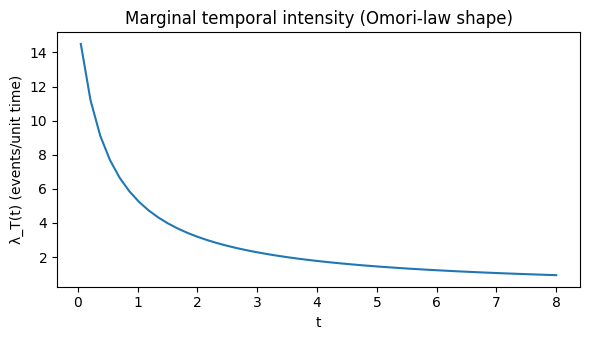

In [5]:
op = IppStOp(
    log_intensity, spatial, temporal, lambda_max=lambda_max, n_integration_points=4096
)
t_grid = jnp.linspace(0.05, float(temporal.t1), 50)
lambda_T = op.marginal_temporal_intensity(t_grid)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t_grid, lambda_T, "C0-")
ax.set_xlabel("t")
ax.set_ylabel("λ_T(t) (events/unit time)")
ax.set_title("Marginal temporal intensity (Omori-law shape)")
plt.tight_layout()
plt.show()

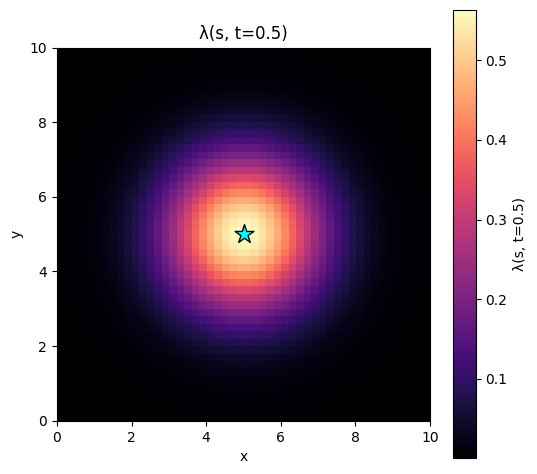

In [6]:
mesh, intensity_surface = op.intensity_surface_at_time(jnp.asarray(0.5), grid_size=50)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(
    intensity_surface.T,
    origin="lower",
    extent=[
        float(spatial.lo[0]),
        float(spatial.hi[0]),
        float(spatial.lo[1]),
        float(spatial.hi[1]),
    ],
    cmap="magma",
)
ax.scatter([5.0], [5.0], marker="*", s=200, color="cyan", edgecolor="k")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("λ(s, t=0.5)")
plt.colorbar(im, ax=ax, label="λ(s, t=0.5)")
plt.tight_layout()
plt.show()

## 2. With NumPyro — recover the epicentre and decay parameters

Treat $A$, $\sigma$, $c$ as unknown and condition on the observed events. Bake the observation into a closure so NumPyro doesn't try to traverse the heterogeneous-shape PyTree.

In [7]:
def model(locs_obs, times_obs, mask_obs, spatial, temporal):
    A = numpyro.sample("A", dist.LogNormal(loc=jnp.log(5.0), scale=0.5))
    sigma = numpyro.sample("sigma", dist.LogNormal(loc=jnp.log(1.5), scale=0.3))
    c = numpyro.sample("c", dist.LogNormal(loc=jnp.log(0.5), scale=0.3))

    def log_lam(s, t):
        spatial_part = -0.5 * jnp.sum((s - epicentre) ** 2, axis=-1) / (sigma**2)
        temporal_part = -jnp.log(c + t)
        return (
            jnp.log(A) + spatial_part + temporal_part - jnp.log(2.0 * jnp.pi * sigma**2)
        )

    spp = IppStDist(
        log_lam,
        spatial=spatial,
        temporal=temporal,
        n_integration_points=2048,
        # Conservative bound that holds across the prior support.
        lambda_max=jnp.asarray(50.0),
    )
    numpyro.factor("lik", spp.log_prob((locs_obs, times_obs, mask_obs)))


mcmc = MCMC(
    NUTS(model), num_warmup=300, num_samples=600, num_chains=1, progress_bar=False
)
mcmc.run(
    random.PRNGKey(1),
    locs_obs=locs,
    times_obs=times,
    mask_obs=mask,
    spatial=spatial,
    temporal=temporal,
)
post = mcmc.get_samples()
for name, true_val in [("A", A_true), ("sigma", sigma_true), ("c", c_true)]:
    samples = post[name]
    print(
        f"{name:>5}: posterior mean = {float(jnp.mean(samples)):.3f}, true = {true_val}"
    )

    A: posterior mean = 5.882, true = 8.0
sigma: posterior mean = 1.634, true = 1.5
    c: posterior mean = 0.525, true = 0.5


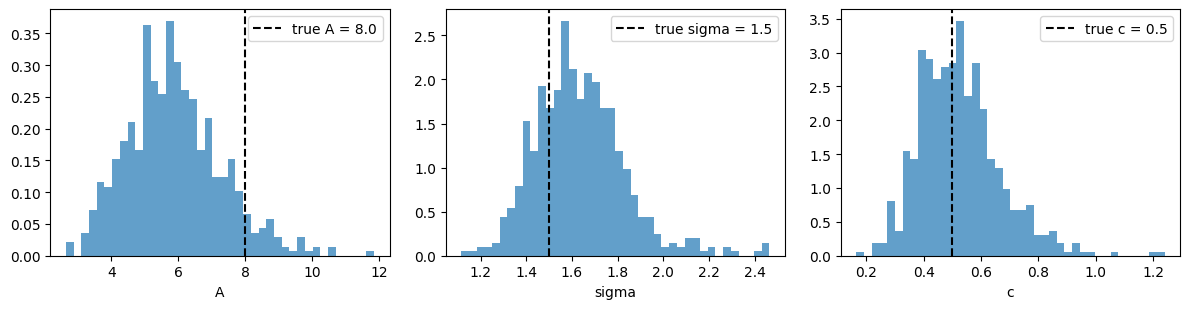

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, name, true_val in zip(axes, ["A", "sigma", "c"], [A_true, sigma_true, c_true]):
    ax.hist(post[name], bins=40, density=True, alpha=0.7, color="C0")
    ax.axvline(true_val, color="k", linestyle="--", label=f"true {name} = {true_val}")
    ax.set_xlabel(name)
    ax.legend()
plt.tight_layout()
plt.show()